# WikiArt Image Explorer

This notebook explores and visualizes images from the WikiArt dataset. It provides tools to understand the structure, metadata, and visual content of the images.

## 1. Import Required Libraries

Import necessary libraries for working with images and file paths.

In [1]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import defaultdict

## 2. Define the Data Path

Define the path to the wikiart folder relative to the src folder using pathlib for cross-platform compatibility.

In [2]:
# Define paths
from IPython.lib.display import FileLink
import json

# Get notebook directory (works in Jupyter/remote)
try:
    from IPython import get_ipython
    notebook_path = Path(get_ipython().kernel.comm_manager.kernels[-1] if hasattr(get_ipython(), 'kernel') else '').resolve()
    # Fallback: assume notebook is in notebooks folder
    if not notebook_path.exists() or notebook_path.is_file():
        notebook_dir = Path.cwd()
    else:
        notebook_dir = notebook_path.parent
except:
    notebook_dir = Path.cwd()

# Navigate to project root - one level up if we're in notebooks folder
project_root = notebook_dir if notebook_dir.name != 'notebooks' else notebook_dir.parent
wikiart_path = project_root / "data" / "wikiart"

print(f"Notebook directory: {notebook_dir}")
print(f"Project root: {project_root}")
print(f"WikiArt path: {wikiart_path}")
print(f"WikiArt folder exists: {wikiart_path.exists()}")

if not wikiart_path.exists():
    # Fallback: try looking for data/wikiart from current directory
    alt_path = Path.cwd() / "data" / "wikiart"
    if alt_path.exists():
        print(f"Found data at alternative location: {alt_path}")
        wikiart_path = alt_path
    else:
        print(f"WARNING: Data folder not found. Expected at: {wikiart_path}")


Notebook directory: /Users/mehmet/src/DeepLearning-NOVAIMS2026/notebooks
Project root: /Users/mehmet/src/DeepLearning-NOVAIMS2026
WikiArt path: /Users/mehmet/src/DeepLearning-NOVAIMS2026/data/wikiart
WikiArt folder exists: True


## 3. List Image Files

Explore the directory structure and count images in the wikiart folder.

In [3]:
# Image extensions to look for
image_extensions = {'.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff', '.webp'}

# Count images by artist folder
image_counts = {}
all_images = []

if wikiart_path.exists():
    for artist_folder in sorted(wikiart_path.iterdir()):
        if artist_folder.is_dir():
            artist_name = artist_folder.name
            images = [f for f in artist_folder.iterdir() 
                     if f.is_file() and f.suffix.lower() in image_extensions]
            image_counts[artist_name] = len(images)
            all_images.extend(images)
    
    print(f"Total artists: {len(image_counts)}")
    print(f"Total images: {len(all_images)}")
    print("\nImages per artist:")
    for artist, count in sorted(image_counts.items(), key=lambda x: x[1], reverse=True):
        print(f"  {artist}: {count} images")
else:
    print(f"WikiArt folder not found at {wikiart_path}")

Total artists: 23
Total images: 13340

Images per artist:
  Vincent_van_Gogh: 1322 images
  Nicholas_Roerich: 1274 images
  Pierre_Auguste_Renoir: 975 images
  Claude_Monet: 934 images
  Pyotr_Konchalovsky: 644 images
  Camille_Pissarro: 621 images
  Albrecht_Durer: 580 images
  John_Singer_Sargent: 549 images
  Rembrandt: 544 images
  Marc_Chagall: 536 images
  Pablo_Picasso: 534 images
  Gustave_Dore: 528 images
  Boris_Kustodiev: 444 images
  Edgar_Degas: 428 images
  Paul_Cezanne: 406 images
  Ivan_Aivazovsky: 404 images
  Martiros_Saryan: 403 images
  Eugene_Boudin: 389 images
  Childe_Hassam: 385 images
  Ilya_Repin: 378 images
  Ivan_Shishkin: 364 images
  Raphael_Kirchner: 362 images
  Salvador_Dali: 336 images


## 4. Display Image Metadata

Extract and display metadata for images such as file size, dimensions, and format.

In [4]:
# Extract metadata for a sample of images
metadata = []

print(f"Total images found: {len(all_images)}")
print(f"Processing first {min(50, len(all_images))} images...\n")

for img_path in all_images[:50]:  # Sample first 50 images
    try:
        size_bytes = img_path.stat().st_size
        size_mb = size_bytes / (1024 * 1024)
        
        with Image.open(img_path) as img:
            width, height = img.size
            img_format = img.format
        
        metadata.append({
            'Artist': img_path.parent.name,
            'Filename': img_path.name,
            'Format': img_format,
            'Width': width,
            'Height': height,
            'Size (MB)': round(size_mb, 3)
        })
    except Exception as e:
        print(f"Error reading {img_path}: {e}")

# Create DataFrame
df = pd.DataFrame(metadata)
print(f"Successfully extracted metadata for {len(df)} images:")
print(df)

# Display statistics only if we have data
if len(df) > 0:
    print(f"\nImage Dimensions Statistics:")
    print(f"Average width: {df['Width'].mean():.0f}px")
    print(f"Average height: {df['Height'].mean():.0f}px")
    print(f"Average file size: {df['Size (MB)'].mean():.3f}MB")
else:
    print("\nWarning: No images were successfully loaded. Check the wikiart folder path and image files.")

Total images found: 13340
Processing first 50 images...

Successfully extracted metadata for 50 images:
            Artist                                           Filename Format  \
0   Albrecht_Durer             albrecht-durer_seated-prophet-1517.jpg   JPEG   
1   Albrecht_Durer              albrecht-durer_self-portrait-1498.jpg   JPEG   
2   Albrecht_Durer  albrecht-durer_hercules-effects-of-jealousy-14...   JPEG   
3   Albrecht_Durer              albrecht-durer_head-of-an-old-man.jpg   JPEG   
4   Albrecht_Durer    albrecht-durer_portrait-of-barent-van-orley.jpg   JPEG   
5   Albrecht_Durer           albrecht-durer_the-holy-trinity-1511.jpg   JPEG   
6   Albrecht_Durer       albrecht-durer_christ-before-pilate-1512.jpg   JPEG   
7   Albrecht_Durer  albrecht-durer_christ-taking-leave-of-his-moth...   JPEG   
8   Albrecht_Durer  albrecht-durer_the-cross-of-christ-with-saint-...   JPEG   
9   Albrecht_Durer                  albrecht-durer_venus-und-amor.jpg   JPEG   
10  Albrecht_Dur

## 5. Visualize Sample Images

Load and display sample images from the wikiart folder in a grid layout.

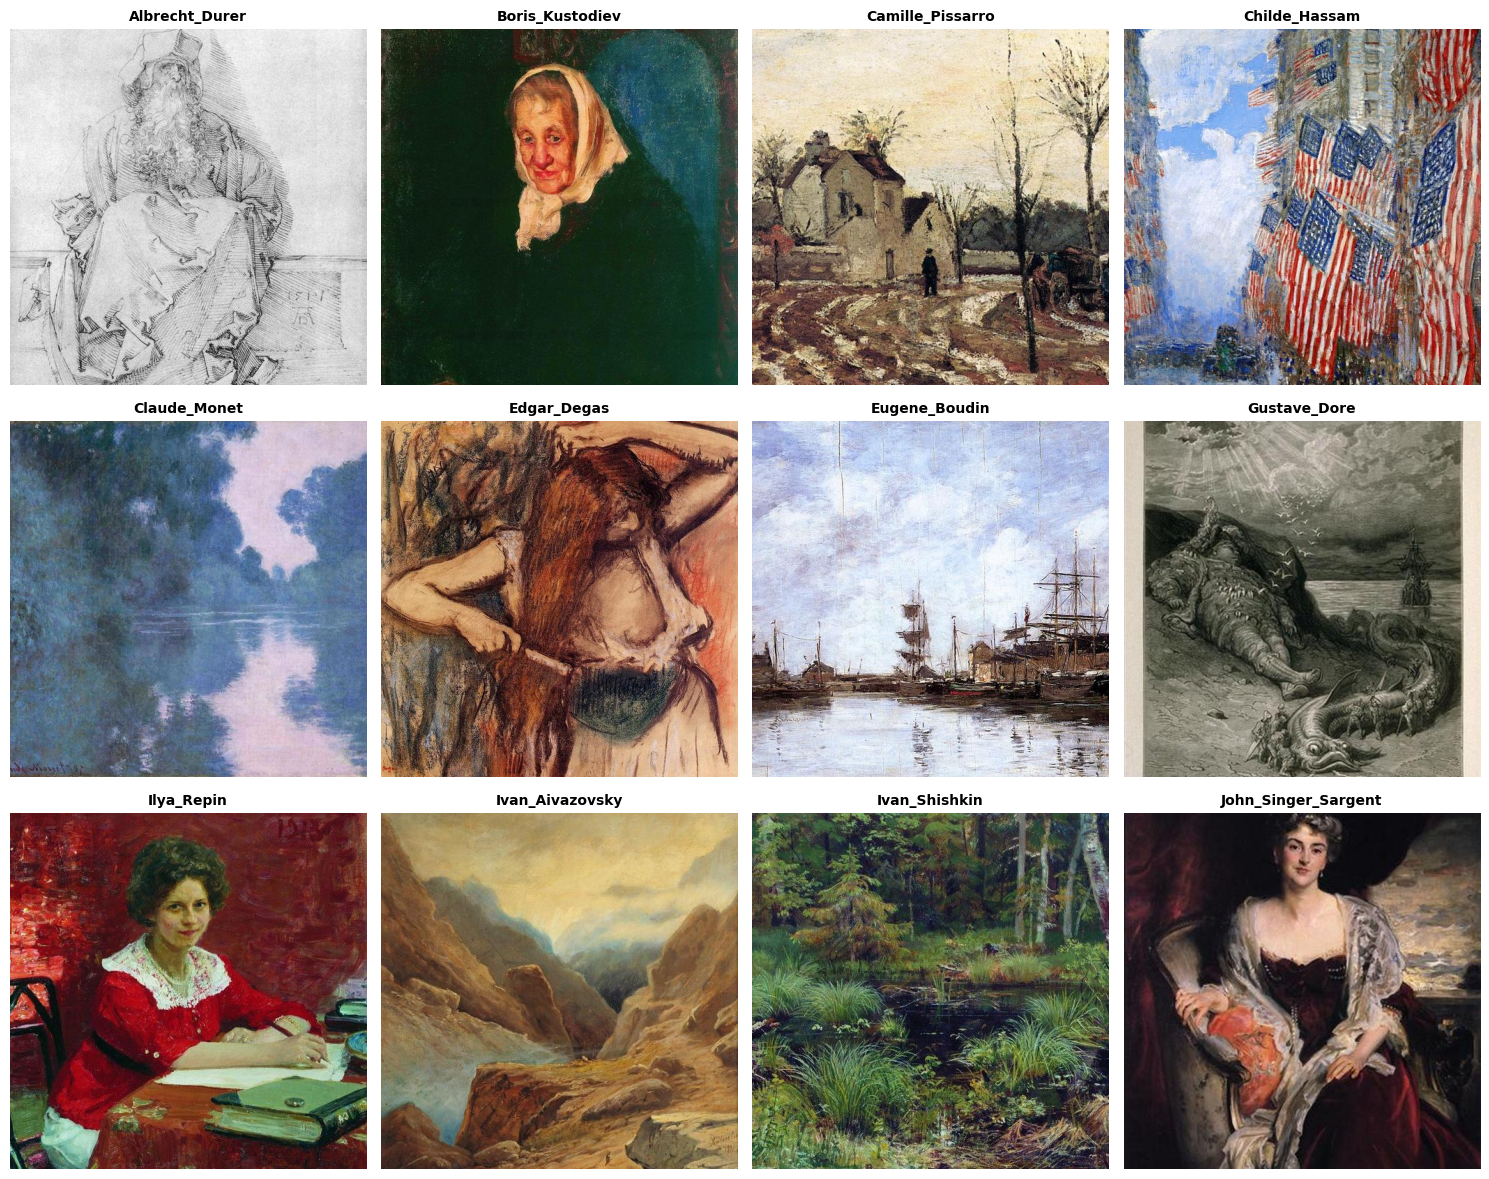

Displayed 12 sample images from different artists


In [5]:
# Display a grid of sample images from different artists
num_samples = 12
rows, cols = 3, 4

fig, axes = plt.subplots(rows, cols, figsize=(15, 12))
axes = axes.flatten()

# Get one image from each artist if possible
sample_images = []
artist_list = list(image_counts.keys())

for i, artist in enumerate(artist_list[:num_samples]):
    artist_path = wikiart_path / artist
    images = [f for f in artist_path.iterdir() 
             if f.is_file() and f.suffix.lower() in image_extensions]
    if images:
        sample_images.append((images[0], artist))

# Display images
for idx, (img_path, artist) in enumerate(sample_images):
    try:
        img = Image.open(img_path)
        axes[idx].imshow(img)
        axes[idx].set_title(artist, fontsize=10, fontweight='bold')
        axes[idx].axis('off')
    except Exception as e:
        axes[idx].text(0.5, 0.5, f'Error loading\n{artist}', ha='center', va='center')
        axes[idx].axis('off')

# Hide remaining subplots
for idx in range(len(sample_images), num_samples):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print(f"Displayed {len(sample_images)} sample images from different artists")